## CTR

### Import Library

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load data

In [28]:
data = pd.read_csv('C:/Tempa_dicoding/projek_akhir/Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/data/data_ml_features.csv')
data

,Konten,Judul video,published_at,Penayangan,Tayangan,durasi_detik,avg_watch_seconds,Poin hype,RPM (IDR),CPM (IDR),...,title_length,title_words,sensational_count,has_symbol,caps_ratio,topic_cluster,topic_score,entity_count,perf_score,performance_class
0,OSDYAzU5v-I,Materi dan Contoh Soal Kurva dan Fungsi Permin...,2020-10-08,52756.0,225089.0,752.0,230.0,0.0,12240.599,11000.418,...,60,10,0,0,0.26,ekonomi_mineral,1,1,202231.333333,bagus
1,OSDYAzU5v-I,Materi dan Contoh Soal Kurva dan Fungsi Permin...,2020-10-08,20639.0,86572.0,752.0,214.0,0.0,9973.259,9337.617,...,60,10,0,0,0.26,ekonomi_mineral,1,1,73612.433333,sedang
2,OSDYAzU5v-I,Materi dan Contoh Soal Kurva dan Fungsi Permin...,2020-10-08,52756.0,225089.0,752.0,230.0,0.0,12240.599,11000.418,...,60,10,0,0,0.26,ekonomi_mineral,1,1,202231.333333,bagus
3,OSDYAzU5v-I,Materi dan Contoh Soal Kurva dan Fungsi Permin...,2020-10-08,20639.0,86572.0,752.0,214.0,0.0,9973.259,9337.617,...,60,10,0,0,0.26,ekonomi_mineral,1,1,73612.433333,sedang
4,OSDYAzU5v-I,Materi dan Contoh Soal Kurva dan Fungsi Permin...,2020-10-08,69724.0,317016.0,752.0,230.0,0.0,11435.701,10644.913,...,60,10,0,0,0.26,ekonomi_mineral,1,1,267275.333333,sangat_bagus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,vxmU8QQk7qw,"KARMA! DULU HINA INDONESIA BABU, KINI RAKYAT M...",2026-04-14,7834.0,48069.0,600.0,234.0,0.0,NaN,6814.133,...,82,12,0,0,1.00,malaysia,1,1,30552.600000,sedang
2996,1AtQ7gnYqpQ,KLAIM TUMPUAN DUNIA! WARGA MALAYSIA NGAMUK BBM...,2026-04-14,10113.0,57232.0,600.0,256.0,0.0,NaN,7606.396,...,96,13,1,0,1.00,malaysia,2,4,43148.800000,sedang
2997,1AtQ7gnYqpQ,KLAIM TUMPUAN DUNIA! WARGA MALAYSIA NGAMUK BBM...,2026-04-14,10113.0,57232.0,600.0,256.0,0.0,NaN,7606.396,...,96,13,1,0,1.00,malaysia,2,4,43148.800000,sedang
2998,O5GDBdSl1Ko,"KONDISI KRITIS! TRUMP DILARIKAN KE RS, TIM MED...",2026-04-14,8189.0,29498.0,600.0,254.0,0.0,NaN,9678.976,...,85,14,0,0,1.00,amerika_barat,1,1,34666.766667,sedang


### EDA

In [45]:
data.columns

Index(['Konten', 'Judul video', 'published_at', 'Penayangan', 'Tayangan',
       'durasi_detik', 'avg_watch_seconds', 'Poin hype', 'RPM (IDR)',
       'CPM (IDR)', 'Persentase penayangan rata-rata (%)', 'like_rate',
       'comment_rate', 'share_rate', 'dislike_ratio', 'engagement_rate',
       'watch_time_ratio', 'revenue_per_view', 'subscriber_net',
       'subscriber_net_per_view', 'ctr', 'impression_to_view_rate',
       'upload_hour', 'upload_day', 'upload_day_name', 'upload_month',
       'upload_year', 'video_age_days', 'duration_bucket', 'title_length',
       'title_words', 'sensational_count', 'has_symbol', 'caps_ratio',
       'topic_cluster', 'topic_score', 'entity_count', 'perf_score',
       'performance_class', 'ctr_effectiveness'],
      dtype='object')

In [51]:
data['ctr'].isnull().sum()

np.int64(0)

In [50]:
data['ctr'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3000 entries, 0 to 2999
Series name: ctr
Non-Null Count  Dtype  
--------------  -----  
3000 non-null   float64
dtypes: float64(1)
memory usage: 23.6 KB


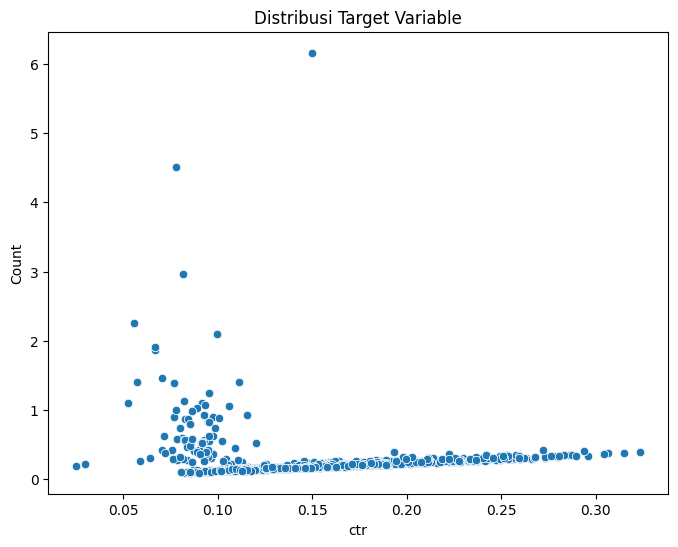

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ctr', y='impression_to_view_rate', data=data)
plt.title('Distribusi Target Variable')
plt.xlabel('ctr')
plt.ylabel('Count')
plt.show()

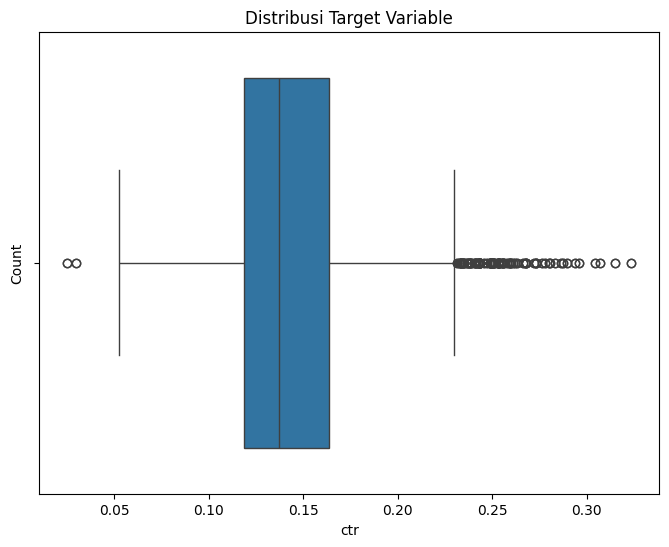

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='ctr', data=data)
plt.title('Distribusi Target Variable')
plt.xlabel('ctr')
plt.ylabel('Count')
plt.show()

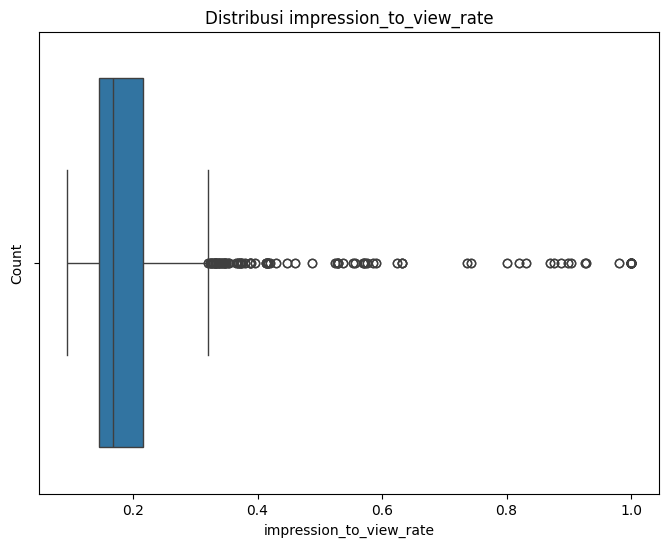

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='impression_to_view_rate', data=data)
plt.title('Distribusi impression_to_view_rate')
plt.xlabel('impression_to_view_rate')
plt.ylabel('Count')
plt.show()

In [34]:
print(data[['ctr', 'impression_to_view_rate']].describe())

               ctr  impression_to_view_rate
count  3000.000000              3000.000000
mean      0.146419                 0.218355
std       0.041992                 0.265012
min       0.025300                 0.094728
25%       0.118475                 0.145769
50%       0.137200                 0.168165
75%       0.163700                 0.215749
max       0.323500                 6.160278


In [35]:
# Lihat berapa banyak data yang nilainya > 1.0 (tidak masuk akal)
outlier_mask = data['impression_to_view_rate'] > 1.0
print(f"Jumlah outlier: {outlier_mask.sum()} dari {len(data)} data")
print(f"Persentase: {outlier_mask.mean()*100:.2f}%")

# Lihat data outliernya seperti apa
print(data[outlier_mask][['Konten', 'Penayangan', 'Tayangan', 'impression_to_view_rate']])

Jumlah outlier: 42 dari 3000 data
Persentase: 1.40%
           Konten  Penayangan  Tayangan  impression_to_view_rate
846   Xp-c4Ft_FVY    134003.0   29759.0                 4.502940
848   Xp-c4Ft_FVY    134003.0   29759.0                 4.502940
1830  BV9I3ZNtLYU     18045.0   16399.0                 1.100372
1831  BV9I3ZNtLYU     18045.0   16399.0                 1.100372
1846  ILQ2GMi4syI     26798.0   19262.0                 1.391237
1847  ILQ2GMi4syI     26798.0   19262.0                 1.391237
1876  ITjEjzuaWUc     22036.0   21384.0                 1.030490
1877  ITjEjzuaWUc     22036.0   21384.0                 1.030490
1888  F8msrjRiBA0     13839.0    9812.0                 1.410416
1889  F8msrjRiBA0     13839.0    9812.0                 1.410416
1932  TT9vZXmFqPA     21096.0   18747.0                 1.125300
1933  TT9vZXmFqPA     21096.0   18747.0                 1.125300
2004  XyRy9YqHoS4     21481.0   19981.0                 1.075071
2005  XyRy9YqHoS4     21481.0   19981.

In [53]:
# Semua nilai > 1.0 diubah jadi 1.0
data['impression_to_view_rate'] = data['impression_to_view_rate'].clip(upper=1.0)

# Verifikasi
print(data[['ctr', 'impression_to_view_rate']].describe())

               ctr  impression_to_view_rate
count  3000.000000              3000.000000
mean      0.146419                 0.205903
std       0.041992                 0.133054
min       0.025300                 0.094728
25%       0.118475                 0.145769
50%       0.137200                 0.168165
75%       0.163700                 0.215749
max       0.323500                 1.000000


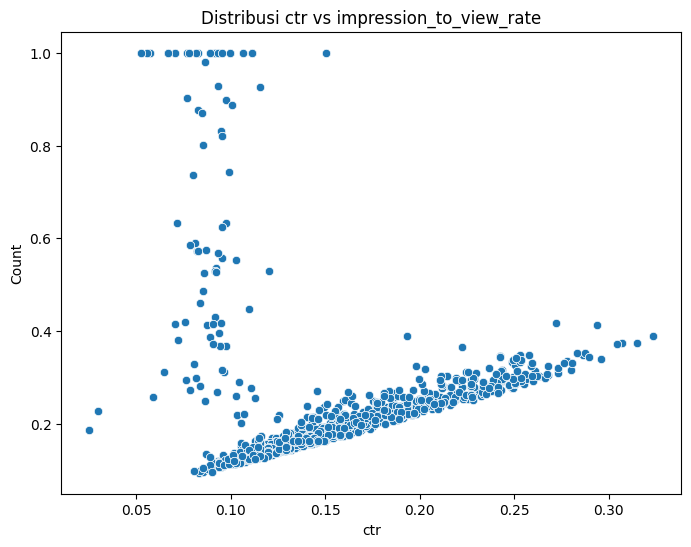

In [57]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ctr', y='impression_to_view_rate', data=data)
plt.title('Distribusi ctr vs impression_to_view_rate')
plt.xlabel('ctr')
plt.ylabel('Count')
plt.show()

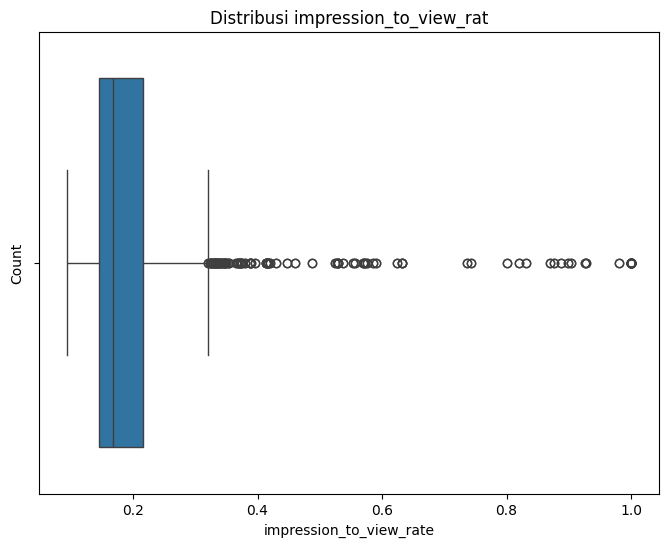

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='impression_to_view_rate', data=data)
plt.title('Distribusi impression_to_view_rat')
plt.xlabel('impression_to_view_rate')
plt.ylabel('Count')
plt.show()

### Feature CTR

In [38]:
# ctr_effectiveness: seberapa efektif CTR menghasilkan views dari tayangan
# Logika: video dengan CTR tinggi DAN impression_to_view_rate tinggi = distribusi sangat efektif
data['ctr_effectiveness'] = data['ctr'] * data['impression_to_view_rate']

# Verifikasi
print(data[['ctr', 'impression_to_view_rate', 'ctr_effectiveness']].describe())
print("\nContoh 5 baris pertama:")
print(data[['ctr', 'impression_to_view_rate', 'ctr_effectiveness']].head())

               ctr  impression_to_view_rate  ctr_effectiveness
count  3000.000000              3000.000000        3000.000000
mean      0.146419                 0.205903           0.030614
std       0.041992                 0.133054           0.019473
min       0.025300                 0.094728           0.004731
25%       0.118475                 0.145769           0.017838
50%       0.137200                 0.168165           0.023570
75%       0.163700                 0.215749           0.036423
max       0.323500                 1.000000           0.150200

Contoh 5 baris pertama:
      ctr  impression_to_view_rate  ctr_effectiveness
0  0.1766                 0.234378           0.041391
1  0.1803                 0.238403           0.042984
2  0.1766                 0.234378           0.041391
3  0.1803                 0.238403           0.042984
4  0.1660                 0.219938           0.036510


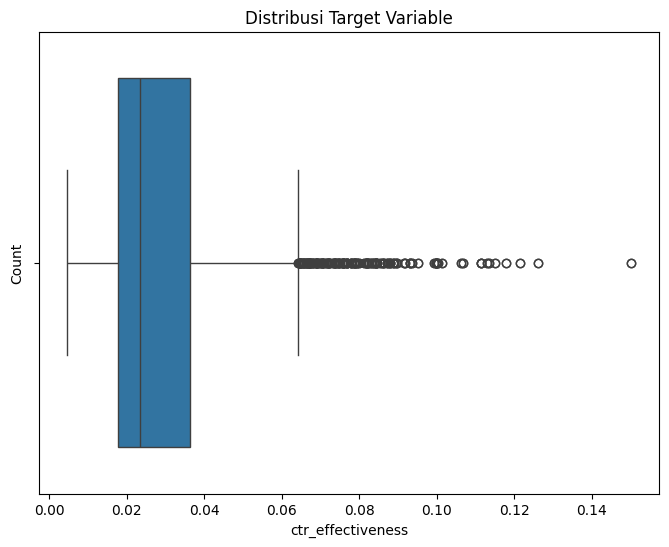

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='ctr_effectiveness', data=data)
plt.title('Distribusi Target Variable')
plt.xlabel('ctr_effectiveness')
plt.ylabel('Count')
plt.show()

In [42]:
data[['perf_score', 'Penayangan', 'engagement_rate', 'revenue_per_view']].corr()

,perf_score,Penayangan,engagement_rate,revenue_per_view
perf_score,1.000000,0.976163,-0.257715,-0.076263
Penayangan,0.976163,1.000000,-0.270655,-0.120636
engagement_rate,-0.257715,-0.270655,1.000000,0.334006
revenue_per_view,-0.076263,-0.120636,0.334006,1.000000


Korelasi fitur CTR ke perf_score:
impression_to_view_rate   -0.167062
ctr                       -0.179955
ctr_effectiveness         -0.222256
Name: perf_score, dtype: float64


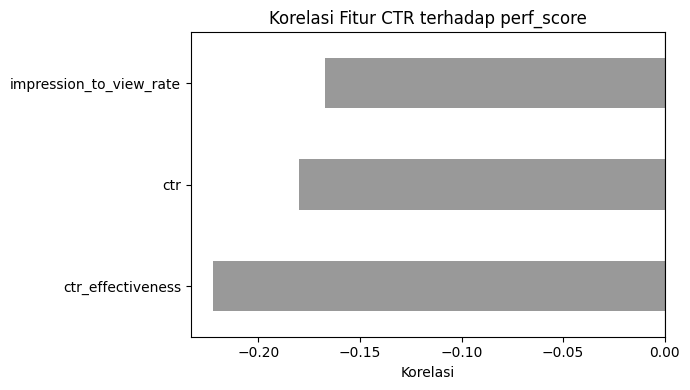

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Korelasi fitur CTR terhadap perf_score
ctr_features = ['ctr', 'impression_to_view_rate', 'ctr_effectiveness']
korelasi = data[ctr_features + ['perf_score']].corr()['perf_score'].drop('perf_score')

print("Korelasi fitur CTR ke perf_score:")
print(korelasi.sort_values(ascending=False))

# Visualisasi
plt.figure(figsize=(7, 4))
korelasi.sort_values().plot(kind='barh', color=['#E05C00' if v > 0 else '#999999' for v in korelasi.sort_values()])
plt.title('Korelasi Fitur CTR terhadap perf_score')
plt.xlabel('Korelasi')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

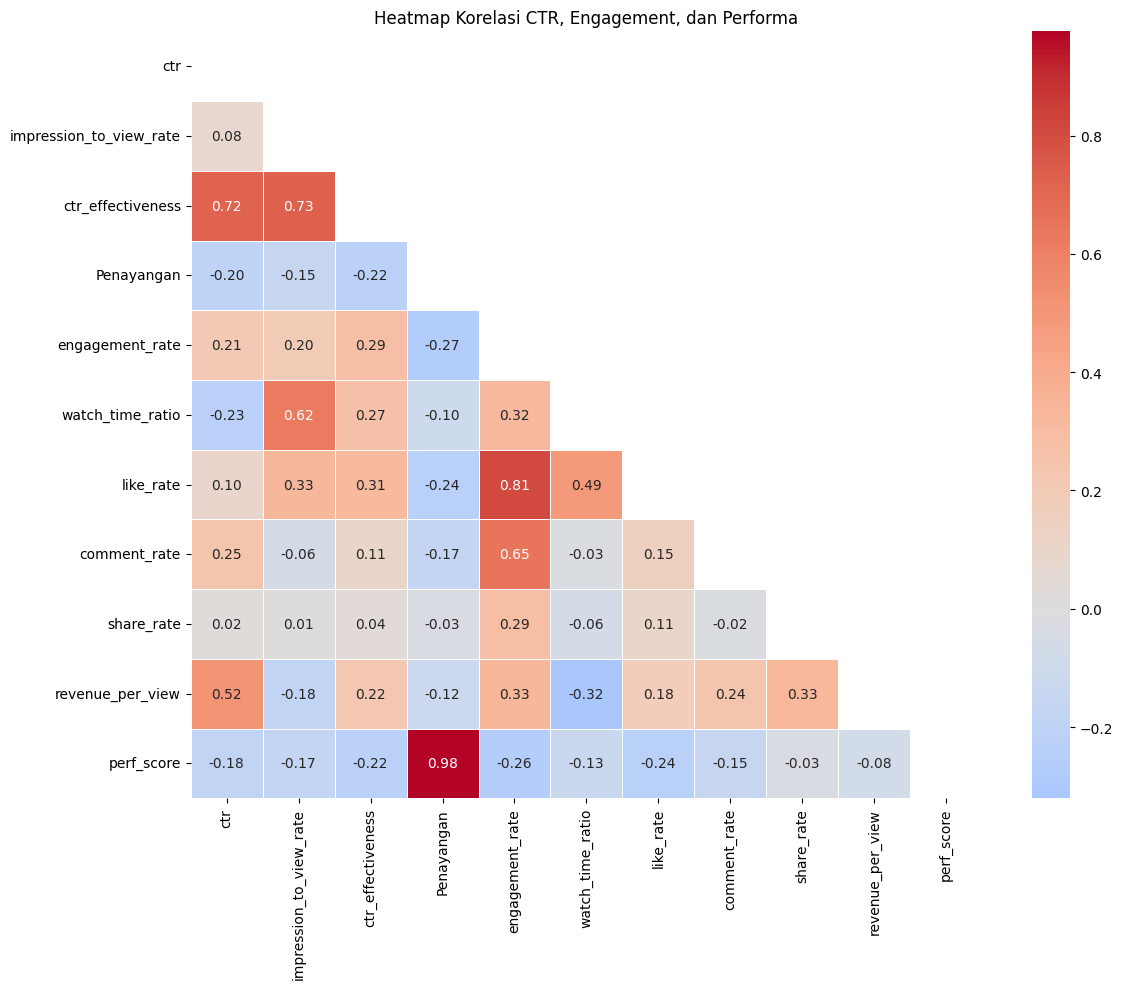

In [59]:
cols = [
    'ctr',
    'impression_to_view_rate',
    'ctr_effectiveness',
    'Penayangan',
    'engagement_rate',
    'watch_time_ratio',
    'like_rate',
    'comment_rate',
    'share_rate',
    'revenue_per_view',
    'perf_score'
]

# 2. Bersihin data (hindari nilai aneh)
data_clean = data[data['impression_to_view_rate'] <= 1].copy()

# 3. Hitung korelasi
corr = data_clean[cols].corr()

# 4. Mask biar lebih rapi (opsional tapi recommended)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 5. Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Heatmap Korelasi CTR, Engagement, dan Performa")
plt.tight_layout()
plt.show()